# SFR Fly Mean-Reversion — 8. Regime and state filters

**Formulation: trade the same signal, but only when the state says to.**

Every framework so far applies one rule to every bar. This one asks whether the
losses are concentrated in identifiable states, and whether gating them out
leaves anything. The gates:

* **Hurst exponent** — H < 0.5 mean-reverting, 0.5 random walk, > 0.5 trending.
  Note the documented trap: under the `std` estimator a *deterministic* drift
  cancels in `x_{t+l} − x_t`, so a strongly drifting fly reads H ≈ 0, not 1.
  (The estimator this replaces returned `2 × slope` and measured H = 1.035 on a
  pure random walk.)
* **Variance ratio** — Lo-MacKinlay, with the heteroskedasticity-robust
  z-statistic, so a conditionally heteroskedastic random walk is not rejected
  as mean-reverting. That matters here: fly vol changes by a factor of three
  between ZIRP and the hiking cycle.
* **ADF** and **half-life** gates — only trade a fly whose recent window is
  actually stationary and reverts on a usable horizon.
* **Realised vol** — the cost is fixed at 1.5bp, so the move has to be big
  enough to pay it.
* **FOMC proximity** — flies price the velocity of the policy path.
* **Curve level and slope** — the macro state.

A gate that helps must beat the ungated rule *after* accounting for the trades
it removed. A filter that only improves the average by deleting trades has not
added information.

In [1]:
CONFIG = dict(
    primary_structure="3m",
    primary_window="liquid16",
    long_window="front8",
    cost_bp=1.5,
    n_packages=100,
    base_z_window=120,
    entry_z=2.0,
    exit_style="z0",
    max_hold=20,
    lag=1,
    state_window=252,
    hurst_max_lag=20,
    vr_k=5,
    fomc_window=5,
)
CONFIG

{'primary_structure': '3m',
 'primary_window': 'liquid16',
 'long_window': 'front8',
 'cost_bp': 1.5,
 'n_packages': 100,
 'base_z_window': 120,
 'entry_z': 2.0,
 'exit_style': 'z0',
 'max_hold': 20,
 'lag': 1,
 'state_window': 252,
 'hurst_max_lag': 20,
 'vr_k': 5,
 'fomc_window': 5}

In [2]:
import sys
from pathlib import Path

sys.path.append("../../")
sys.path.append(str(Path.cwd()))

import dataclasses

import numpy as np
import pandas as pd

import matplotlib
if "ipykernel" not in sys.modules:
    matplotlib.use("Agg")
import matplotlib.pyplot as plt

from RVUtils.MeanRev import MRConfig, run_backtest
from RVUtils.MeanRev.signals import zscore_signal
from RVUtils.mean_reversion import (
    adf_pvalue, half_life, hurst_exponent, rolling_half_life, rolling_hurst,
    variance_ratio, variance_ratio_stat,
)
from sfr_fly_meanrev_common import (
    header_block, league_row, load_lab, regime_block, shadow_block,
    three_panel_equity,
)

pd.set_option("display.width", 230)
pd.set_option("display.max_columns", 60)

BASE = MRConfig(lag=CONFIG["lag"], round_trip_cost_bp=CONFIG["cost_bp"],
                max_hold=CONFIG["max_hold"], n_packages=CONFIG["n_packages"],
                entry_z=CONFIG["entry_z"], exit_style=CONFIG["exit_style"])
lab = load_lab(CONFIG["primary_structure"], CONFIG["primary_window"])
levels, gate0, st = lab["levels"], lab["gate"], lab["struct"]
sig = zscore_signal(levels, window=CONFIG["base_z_window"])
print(f"{levels.shape[1]} flies, {levels.shape[0]} sessions")

34 flies, 1150 sessions


## 1. Full-sample state statistics per fly

Before gating anything: are these series mean-reverting at all by the standard
diagnostics?

In [3]:
rows = []
for c in levels.columns:
    s = levels[c].dropna()
    if len(s) < 300:
        continue
    vr = variance_ratio_stat(s, k=CONFIG["vr_k"])
    rows.append({"key": c, "n": len(s), "sd_bp": s.std(),
                 "hurst_std": hurst_exponent(s, max_lag=100, method="std"),
                 "hurst_rs": hurst_exponent(s, max_lag=100, method="rs", min_lag=10),
                 "vr5": vr["vr"], "vr_z": vr["z"], "vr_p": vr["pvalue"],
                 "adf_p": adf_pvalue(s), "hl": half_life(s)})
state = pd.DataFrame(rows)
print(state.round(3).to_string(index=False))
print("\nsummary:")
print(state[["hurst_std", "hurst_rs", "vr5", "vr_z", "adf_p", "hl"]]
      .describe().round(3).to_string())
print(f"\n  H < 0.5 (mean-reverting) on {int((state['hurst_std'] < 0.5).sum())}"
      f"/{len(state)} keys")
print(f"  VR < 1 on {int((state['vr5'] < 1).sum())}/{len(state)}; "
      f"VR significantly < 1 (z < -1.96) on {int((state['vr_z'] < -1.96).sum())}")
print(f"  ADF stationary at 10% on {int((state['adf_p'] < 0.10).sum())}/{len(state)}")

        key   n  sd_bp  hurst_std  hurst_rs   vr5   vr_z  vr_p  adf_p     hl
H23-M23-U23 300  9.282      0.415     0.597 0.420 -1.577 0.115  0.434 13.916
H24-M24-U24 556  6.493      0.402     0.559 0.860 -0.975 0.329  0.239 42.026
H25-M25-U25 806  4.052      0.479     0.465 0.791 -1.967 0.049  0.210 43.043
H26-M26-U26 876  3.072      0.443     0.361 0.650 -3.376 0.001  0.458 47.002
H27-M27-U27 718  1.860      0.397     0.323 0.423 -5.434 0.000  0.854 23.052
H28-M28-U28 468  0.658      0.205     0.239 0.229 -7.296 0.000  0.583  3.143
M23-U23-Z23 368  7.792      0.244     0.544 0.994 -0.018 0.986  0.393 18.740
M24-U24-Z24 619  5.731      0.482     0.534 0.873 -1.118 0.264  0.838 98.270
M25-U25-Z25 869  3.180      0.295     0.449 0.812 -1.459 0.145  0.225 40.673
M26-U26-Z26 876  3.619      0.409     0.447 0.735 -2.176 0.030  0.300 57.442
M27-U27-Z27 654  1.064      0.309     0.380 0.370 -6.764 0.000  0.194  7.998
M28-U28-Z28 404  0.398      0.118     0.184 0.253 -6.526 0.000  0.011  1.052

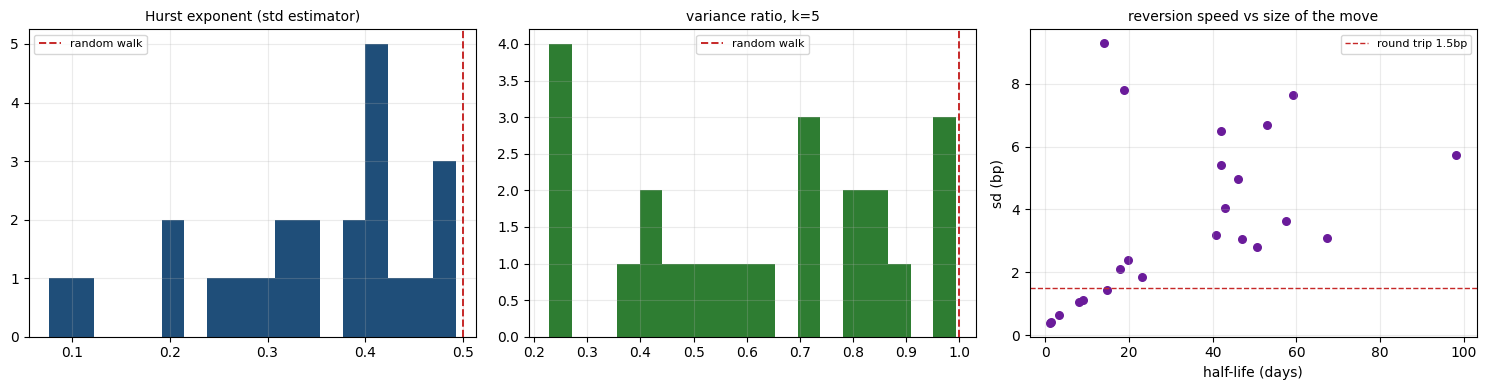

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].hist(state["hurst_std"].dropna(), bins=18, color="#1f4e79")
axes[0].axvline(0.5, color="#c62828", lw=1.4, ls="--", label="random walk")
axes[0].set_title("Hurst exponent (std estimator)", fontsize=10)
axes[0].legend(fontsize=8)
axes[1].hist(state["vr5"].dropna(), bins=18, color="#2e7d32")
axes[1].axvline(1.0, color="#c62828", lw=1.4, ls="--", label="random walk")
axes[1].set_title(f"variance ratio, k={CONFIG['vr_k']}", fontsize=10)
axes[1].legend(fontsize=8)
axes[2].scatter(state["hl"], state["sd_bp"], s=30, color="#6a1b9a")
axes[2].set_xlabel("half-life (days)")
axes[2].set_ylabel("sd (bp)")
axes[2].axhline(CONFIG["cost_bp"], color="#c62828", ls="--", lw=1.0,
                label=f"round trip {CONFIG['cost_bp']}bp")
axes[2].set_title("reversion speed vs size of the move", fontsize=10)
axes[2].legend(fontsize=8)
for a in axes:
    a.grid(alpha=0.25)
fig.tight_layout()
plt.show()

## 2. Build the state panels

All trailing, all causal.

In [5]:
W = CONFIG["state_window"]
hurst_p = pd.DataFrame({c: rolling_hurst(levels[c], window=W,
                                         max_lag=CONFIG["hurst_max_lag"], step=5)
                        for c in levels.columns}).reindex(levels.index)
hl_p = pd.DataFrame({c: rolling_half_life(levels[c], window=W)
                     for c in levels.columns}).reindex(levels.index)
vol_p = levels.diff().rolling(21, min_periods=10).std() * np.sqrt(252)
adf_p = pd.DataFrame(index=levels.index, columns=levels.columns, dtype=float)
for c in levels.columns:
    s = levels[c]
    vals = pd.Series(np.nan, index=s.index)
    for i in range(W - 1, len(s), 10):
        vals.iloc[i] = adf_pvalue(s.iloc[i - W + 1:i + 1])
    adf_p[c] = vals.ffill()

# curve level and slope from the strip
sp = lab["slot_panel"]
lvl = sp[[c for c in sp.columns if c <= 4]].mean(axis=1)
slope = (sp[[c for c in sp.columns if 13 <= c <= 16]].mean(axis=1)
         - sp[[c for c in sp.columns if c <= 4]].mean(axis=1)) * 100
lvl = lvl.reindex(levels.index).ffill()
slope = slope.reindex(levels.index).ffill()
print(f"state panels built: hurst {hurst_p.notna().to_numpy().mean():.0%} filled, "
      f"half-life {hl_p.notna().to_numpy().mean():.0%}, "
      f"adf {adf_p.notna().to_numpy().mean():.0%}")

state panels built: hurst 56% filled, half-life 16%, adf 57%


## 3. FOMC proximity

Meeting dates come from the same repo helper the curve builder uses.

In [6]:
try:
    from MDP.IRSwaps.SDR_INTRADAY.rl_curve_utils.stir_curve_building_utils import (
        get_fomc_meetings_list,
    )
    raw = get_fomc_meetings_list(as_of=levels.index[0].date(), n_plus_years=8)
    fomc = sorted({pd.Timestamp(getattr(d, "date", lambda: d)()
                                if not isinstance(d, pd.Timestamp) else d).normalize()
                   for d in raw})
    fomc = [d for d in fomc if levels.index[0] <= d <= levels.index[-1]]
except Exception as exc:
    print(f"FOMC list unavailable: {type(exc).__name__}: {exc}")
    fomc = []
print(f"{len(fomc)} FOMC dates inside the window")
days_to = pd.Series(np.nan, index=levels.index)
if fomc:
    fa = np.array([d.value for d in fomc])
    for i, d in enumerate(levels.index):
        diff = (fa - d.value) / 86_400_000_000_000
        fut = diff[diff >= 0]
        days_to.iloc[i] = fut.min() if len(fut) else np.nan

37 FOMC dates inside the window


## 4. Gate sweep

Each gate is applied on top of the identical base signal and config, so the
only thing that changes is which bars are eligible to open a trade.

In [7]:
def run_gate(name, mask):
    g = gate0 & mask.reindex(index=levels.index, columns=levels.columns).fillna(False)
    r = run_backtest(BASE, levels=levels, signal=sig, gate=g)
    m = r.metrics
    return {"gate": name, "bars_open_pct": float(g.to_numpy().mean()),
            "n_trades": m["n_trades"], "hit_rate": m["hit_rate"],
            "avg_net_bp": m["avg_net_bp"], "total_net_bp": m["total_net_bp"],
            "total_gross_bp": m["total_gross_bp"], "sharpe": m["sharpe"],
            "max_dd_bp": m["max_dd_bp"]}, r


ALL = pd.DataFrame(True, index=levels.index, columns=levels.columns)
gates = {
    "none (base)": ALL,
    "Hurst < 0.45": hurst_p < 0.45,
    "Hurst < 0.40": hurst_p < 0.40,
    "Hurst > 0.55 (trending)": hurst_p > 0.55,
    "half-life 3-60d": (hl_p >= 3) & (hl_p <= 60),
    "half-life 3-20d": (hl_p >= 3) & (hl_p <= 20),
    "ADF p < 0.10": adf_p < 0.10,
    "ADF p < 0.05": adf_p < 0.05,
    "realised vol top half": vol_p.gt(vol_p.median(axis=1), axis=0),
    "realised vol bottom half": vol_p.lt(vol_p.median(axis=1), axis=0),
}
if fomc:
    near = pd.DataFrame(np.repeat((days_to <= CONFIG["fomc_window"]).to_numpy()[:, None],
                                  levels.shape[1], axis=1),
                        index=levels.index, columns=levels.columns)
    gates[f"within {CONFIG['fomc_window']}d before FOMC"] = near
    gates[f"more than {CONFIG['fomc_window']}d from FOMC"] = ~near
steep = pd.DataFrame(np.repeat((slope > slope.median()).to_numpy()[:, None],
                               levels.shape[1], axis=1),
                     index=levels.index, columns=levels.columns)
gates["curve steep (upper half)"] = steep
gates["curve flat/inverted (lower half)"] = ~steep
high = pd.DataFrame(np.repeat((lvl > lvl.median()).to_numpy()[:, None],
                              levels.shape[1], axis=1),
                    index=levels.index, columns=levels.columns)
gates["front rates above median"] = high
gates["front rates below median"] = ~high

rows, results = [], {}
for name, mask in gates.items():
    row, r = run_gate(name, mask)
    rows.append(row)
    results[name] = r
gate_tbl = pd.DataFrame(rows).sort_values("total_net_bp", ascending=False)
print(gate_tbl.round(3).to_string(index=False))

                            gate  bars_open_pct  n_trades  hit_rate  avg_net_bp  total_net_bp  total_gross_bp  sharpe  max_dd_bp
         Hurst > 0.55 (trending)          0.004         3     0.333      -0.250         -0.75            3.75  -0.222      -9.25
                 half-life 3-20d          0.074        68     0.206      -1.239        -84.25           17.75  -1.645     -94.25
                 half-life 3-60d          0.118        93     0.215      -1.239       -115.25           24.25  -1.351    -149.75
                    ADF p < 0.05          0.096       113     0.044      -1.283       -145.00           24.50  -3.336    -147.00
           within 5d before FOMC          0.052       124     0.113      -1.401       -173.75           12.25  -1.725    -186.50
curve flat/inverted (lower half)          0.206       170     0.165      -1.054       -179.25           75.75  -1.236    -188.75
        front rates above median          0.206       169     0.136      -1.065       -180.00    

In [8]:
base_row = gate_tbl[gate_tbl["gate"] == "none (base)"].iloc[0]
gate_tbl["vs_base_net_bp"] = gate_tbl["total_net_bp"] - base_row["total_net_bp"]
gate_tbl["net_bp_per_trade_vs_base"] = (gate_tbl["avg_net_bp"]
                                        - base_row["avg_net_bp"])
print("\nchange versus the ungated rule (a gate that only deletes trades is not "
      "information):")
print(gate_tbl[["gate", "bars_open_pct", "n_trades", "avg_net_bp",
                "net_bp_per_trade_vs_base", "total_net_bp", "vs_base_net_bp"]]
      .round(3).to_string(index=False))


change versus the ungated rule (a gate that only deletes trades is not information):
                            gate  bars_open_pct  n_trades  avg_net_bp  net_bp_per_trade_vs_base  total_net_bp  vs_base_net_bp
         Hurst > 0.55 (trending)          0.004         3      -0.250                     0.982         -0.75          430.50
                 half-life 3-20d          0.074        68      -1.239                    -0.007        -84.25          347.00
                 half-life 3-60d          0.118        93      -1.239                    -0.007       -115.25          316.00
                    ADF p < 0.05          0.096       113      -1.283                    -0.051       -145.00          286.25
           within 5d before FOMC          0.052       124      -1.401                    -0.169       -173.75          257.50
curve flat/inverted (lower half)          0.206       170      -1.054                     0.178       -179.25          252.00
        front rates above median

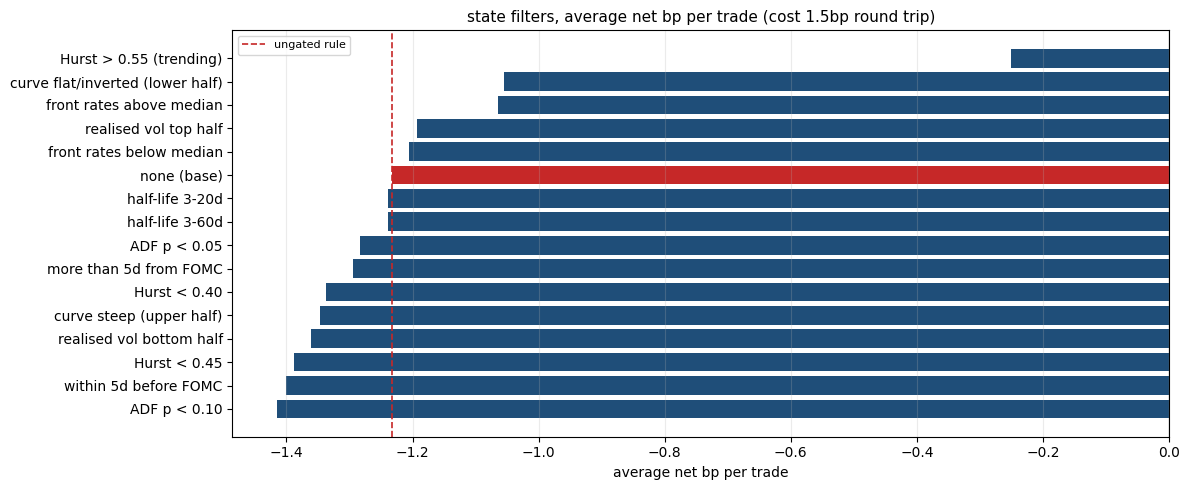

In [9]:
fig, ax = plt.subplots(figsize=(12, 5))
g = gate_tbl.sort_values("avg_net_bp")
colors = ["#c62828" if v == "none (base)" else "#1f4e79" for v in g["gate"]]
ax.barh(g["gate"], g["avg_net_bp"], color=colors)
ax.axvline(0, color="grey", lw=0.9)
ax.axvline(base_row["avg_net_bp"], color="#c62828", ls="--", lw=1.2,
           label="ungated rule")
ax.set_xlabel("average net bp per trade")
ax.set_title("state filters, average net bp per trade "
             f"(cost {CONFIG['cost_bp']}bp round trip)", fontsize=11)
ax.legend(fontsize=8)
ax.grid(alpha=0.25, axis="x")
fig.tight_layout()
plt.show()

## 5. Best gate — full treatment

The best row above is by construction the best of ~15 tried, so it gets the
same scrutiny as any other selected config: regime split, shadow
decomposition, and a league row that charges the search.

unrestricted best gate: 'Hurst > 0.55 (trending)' with only 3 trades (-0.75bp) -- a small-sample artifact, so the headline gate is the best one with at least 30 trades: 'half-life 3-20d'
8. Best state filter: half-life 3-20d  |  fade|z2.0|z0|hold20|lag1|every1|c1.5  |  100 packages ($2,500/bp, 400 contracts)
  best of 16 gates with >=30 trades, on the same base signal and config
  trades    68   skipped    0   hit 21%   avg -1.239bp   avg hold 17.6d
  total     -84.25bp   $     -210,625   gross +17.75bp
  daily-MTM Sharpe -1.64   maxDD -94.25bp ($-235,625)   worst trade -4.50bp
  t(trade) -4.38   NW t(daily) -2.93   non-overlap SR -0.29   DSR p=0.000 over 16 trials


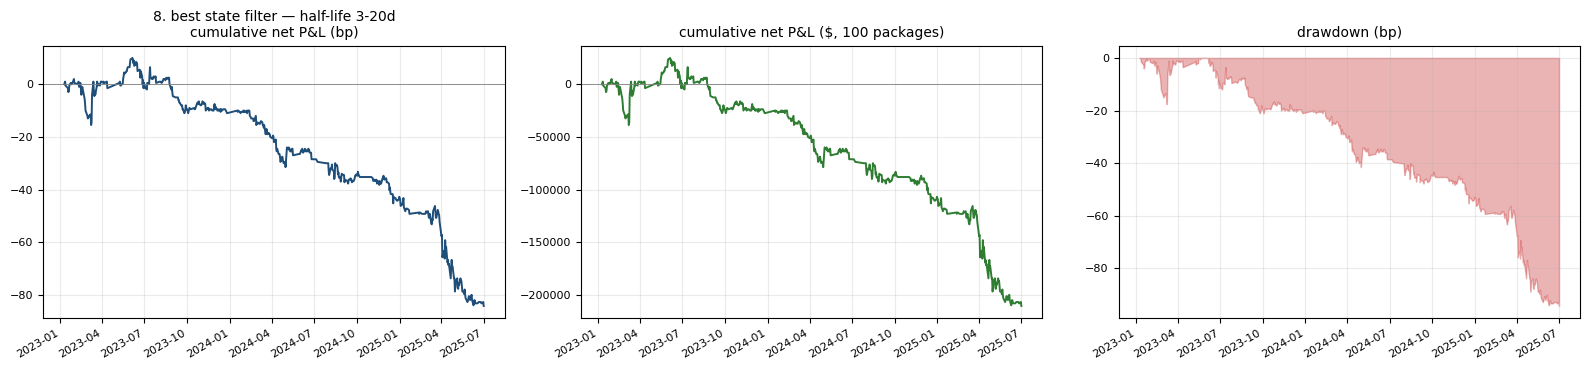


REGIME SPLIT (a single six-year parameter set is the thing being tested)
 regime  n_trades  n_days  hit_rate  avg_net_bp  total_net_bp  total_net_usd  daily_sharpe
   ZIRP         0       0       NaN         NaN          0.00            0.0           NaN
 HIKING        15     116     0.467       0.033          0.50         1250.0         0.036
PLATEAU        24     241     0.167      -1.490        -35.75       -89375.0        -2.183
CUTTING        29     166     0.103      -1.690        -49.00      -122500.0        -2.534



LINEAR-SHADOW DECOMPOSITION (same signal, simpler instrument, own cost)
    instrument  n_legs  round_trip_bp  n_trades  total_gross_bp  total_net_bp  avg_net_bp  hit_rate  sharpe  max_dd_bp  avg_hold  beats_fly_net  beats_fly_sharpe
           fly       3            1.5       350            93.8        -431.2      -1.232     0.131  -1.884     -434.8      14.7          False             False
         belly       1            0.5       350           257.0          82.0       0.234     0.449   0.051     -905.5      14.7           True              True
belly_vs_front       2            1.0       350          -168.2        -518.2      -1.481     0.246  -1.580     -540.8      14.7          False              True
 belly_vs_back       2            1.0       350           262.0         -88.0      -0.251     0.331  -0.380     -174.5      14.7           True              True
  -> SHADOWED - a simpler instrument beats the fly on net bp

  LEAGUE ROW  8. Regime/state filter / best-gate: MARGI

{'framework': '8. Regime/state filter',
 'variant': 'median-gate',
 'class': 'state',
 'structure': '3m',
 'window': 'liquid16',
 'config': 'fade|z2.0|z0|hold20|lag1|every1|c1.5',
 'n_trades': 135,
 'hit_rate': 0.044444444444444446,
 'avg_net_bp': -1.4148148148148147,
 'total_gross_bp': 11.5,
 'total_net_bp': -191.0,
 'total_net_usd': -477500.0,
 'net_bp_maker': 11.5,
 'net_bp_taker': -326.0,
 'net_usd_taker': -815000.0,
 'sharpe': -3.5647098903855934,
 'max_dd_bp': -194.5000000000408,
 'max_dd_usd': -486250.00000010204,
 'avg_hold_days': 11.977777777777778,
 'dsr_prob': 9.444750821240337e-23,
 'grid_median_net_bp': -206.375,
 'nonoverlap_sharpe': -1.2746728169287795,
 'verdict': 'MARGINAL-maker-only',
 'note': 'median gate of the sweep: ADF p < 0.10'}

In [10]:
raw_best = gate_tbl.iloc[0]
usable = gate_tbl[gate_tbl["n_trades"] >= 30]
best_name = (usable.iloc[0]["gate"] if not usable.empty else raw_best["gate"])
best_res = results[best_name]
print(f"unrestricted best gate: {raw_best['gate']!r} with only "
      f"{int(raw_best['n_trades'])} trades ({raw_best['total_net_bp']:+.2f}bp) -- "
      f"a small-sample artifact, so the headline gate is the best one with at "
      f"least 30 trades: {best_name!r}")
pseudo_grid = pd.DataFrame({"total_net_bp": gate_tbl["total_net_bp"].to_numpy(),
                            "sharpe": gate_tbl["sharpe"].to_numpy(),
                            "n_trades": gate_tbl["n_trades"].to_numpy()})
header_block(f"8. Best state filter: {best_name}", best_res, grid=pseudo_grid,
             note=f"best of {len(gate_tbl)} gates with >=30 trades, on the same "
                  f"base signal and config")
three_panel_equity(best_res, f"8. best state filter — {best_name}")
plt.show()
regime_block(best_res, lab["regimes"], framework="8. Regime/state filter")
shadow_block(sig, lab, BASE, framework="8. Regime/state filter")
league_row("8. Regime/state filter", "best-gate", best_res, grid=pseudo_grid,
           cls="state",
           note=f"best of {len(gate_tbl)} gates with >=30 trades: {best_name}",
           window=str(lab["window"]), structure=str(lab["structure"]))

med_i = (gate_tbl["total_net_bp"] - gate_tbl["total_net_bp"].median()).abs().idxmin()
med_name = gate_tbl.loc[med_i, "gate"]
league_row("8. Regime/state filter", "median-gate", results[med_name],
           grid=pseudo_grid, cls="state",
           note=f"median gate of the sweep: {med_name}",
           window=str(lab["window"]), structure=str(lab["structure"]))

## 6. Does the base rule work in ANY single regime?

The most direct version of the sample-composition question: fit and trade
inside one regime at a time.

In [11]:
reg = lab["regimes"]
rows = []
for name in ["ZIRP", "HIKING", "PLATEAU", "CUTTING"]:
    m = (reg == name).reindex(levels.index).fillna(False)
    if int(m.sum()) < 100:
        continue
    sub_lv = levels[m.to_numpy()]
    sub_sig = zscore_signal(sub_lv, window=CONFIG["base_z_window"])
    r = run_backtest(BASE, levels=sub_lv, signal=sub_sig,
                     gate=gate0[m.to_numpy()])
    mm = r.metrics
    rows.append({"regime": name, "n_days": int(m.sum()), "n_trades": mm["n_trades"],
                 "hit_rate": mm["hit_rate"], "avg_net_bp": mm["avg_net_bp"],
                 "total_gross_bp": mm["total_gross_bp"],
                 "total_net_bp": mm["total_net_bp"], "sharpe": mm["sharpe"]})
print("z-score fade FITTED AND TRADED inside one regime at a time:")
print(pd.DataFrame(rows).round(3).to_string(index=False))

z-score fade FITTED AND TRADED inside one regime at a time:
 regime  n_days  n_trades  hit_rate  avg_net_bp  total_gross_bp  total_net_bp  sharpe
 HIKING     342        92     0.261      -0.595           83.25        -54.75  -0.554
PLATEAU     288        79     0.114      -1.551           -4.00       -122.50  -3.299
CUTTING     469       149     0.067      -1.559           -8.75       -232.25  -3.741
